# Cargar y preparar los datos:

In [1]:
# Cargar los datos
import pandas as pd

# Cargar archivos
df_calendar = pd.read_excel('DIM_CALENDAR (2).xlsx')
df_product = pd.read_excel('DIM_PRODUCT (1).xlsx')
df_category = pd.read_csv('DIM_CATEGORY (2).csv')
df_segment = pd.read_excel('DIM_SEGMENT (1).xlsx')
df_sales = pd.read_csv('FACT_SALES (1).csv')

In [2]:
# Revisión inicial de datos
print(df_sales.head())
print(df_sales.info())
print(df_sales.describe())

# Revisar valores nulos
print(df_sales.isnull().sum())

    WEEK         ITEM_CODE  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  \
0  34-22  7501058792808BP2             0.006              0.139   
1  34-22     7501058715883             0.487            116.519   
2  34-22     7702626213774             1.391             68.453   
3  34-22     7501058716422             0.022              1.481   
4  34-22     7501058784353             2.037            182.839   

   TOTAL_UNIT_AVG_WEEKLY_SALES              REGION  
0                        1.000  TOTAL AUTOS AREA 5  
1                        2.916  TOTAL AUTOS AREA 5  
2                        5.171  TOTAL AUTOS AREA 5  
3                        1.833  TOTAL AUTOS AREA 5  
4                        5.375  TOTAL AUTOS AREA 5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  

# Seleccionar las características para el clustering:

In [3]:
print("FACT_SALES:")
print(df_sales.columns)

print("\nDIM_PRODUCT:")
print(df_product.columns)

print("\nDIM_CATEGORY:")
print(df_category.columns)

print("\nDIM_SEGMENT:")
print(df_segment.columns)

print("\nDIM_CALENDAR:")
print(df_calendar.columns)

FACT_SALES:
Index(['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
       'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION'],
      dtype='object')

DIM_PRODUCT:
Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3'],
      dtype='object')

DIM_CATEGORY:
Index(['ID_CATEGORY', 'CATEGORY'], dtype='object')

DIM_SEGMENT:
Index(['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT'], dtype='object')

DIM_CALENDAR:
Index(['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE'], dtype='object')


In [4]:
# Base de Ventas
df_features = df_sales[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']].copy()

# Categoría del Producto
df_temp = df_sales.merge(df_product, left_on = 'ITEM_CODE', right_on = 'ITEM', how = 'left')

# Segmento
df_temp = df_temp.merge(df_segment, on = ['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT'], how = 'left')

# Selección final de variables
df_features = df_temp[['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION', 'CATEGORY', 'SEGMENT']].copy()

# Convertir Categóricas a Numéricas
df_features = pd.get_dummies(df_features, drop_first = True)

Se realizó la selección de las características clave para el análisis de clustering a partir del conjunto de datos disponible. Se eligieron variables numéricas relevantes como el total de unidades vendidas (TOTAL_UNIT_SALES), el valor total de ventas (TOTAL_VALUE_SALES) y el promedio semanal de ventas (TOTAL_UNIT_AVG_WEEKLY_SALES), las cuales permiten analizar el comportamiento comercial de los productos.

Adicionalmente, se incorporaron variables categóricas como la región geográfica (REGION), la categoría del producto (CATEGORY) y el segmento (SEGMENT), obtenidas mediante la integración de las tablas dimensionales. Estas variables fueron transformadas a formato numérico mediante técnicas de codificación, con el fin de ser utilizadas en el modelo de clustering.

La combinación de estas variables permite generar una segmentación más completa, considerando tanto el desempeño en ventas como las características del producto y su distribución geográfica.

# Estandarizar las características:

In [5]:
# Estandarizar las características

from sklearn.preprocessing import StandardScaler

# Crear escalador
scaler = StandardScaler()

# Aplicar escalado
df_scaled = scaler.fit_transform(df_features)

# Ver resultado (opcional)
print(df_scaled[:5])

[[-0.22110293 -0.2580403  -0.40176089  0.         -0.42284448 -0.39541282
  -0.40486924  2.5615086  -0.401173   -0.45584766 -0.88001119 -0.4780779
  -0.06790622  2.42798387 -0.43140369 -0.20721808]
 [-0.18792124  0.07425081 -0.31716946  0.         -0.42284448 -0.39541282
  -0.40486924  2.5615086  -0.401173   -0.45584766 -0.88001119 -0.4780779
  -0.06790622  2.42798387 -0.43140369 -0.20721808]
 [-0.12555899 -0.06298844 -0.21761118  0.         -0.42284448 -0.39541282
  -0.40486924  2.5615086  -0.401173   -0.45584766 -0.88001119 -0.4780779
  -0.06790622  2.42798387 -0.43140369 -0.20721808]
 [-0.21999917 -0.25420858 -0.36498393  0.         -0.42284448 -0.39541282
  -0.40486924  2.5615086  -0.401173   -0.45584766 -0.88001119 -0.4780779
  -0.06790622  2.42798387 -0.43140369 -0.20721808]
 [-0.08099482  0.26360935 -0.20860458  0.         -0.42284448 -0.39541282
  -0.40486924  2.5615086  -0.401173   -0.45584766 -0.88001119 -0.4780779
  -0.06790622  2.42798387 -0.43140369 -0.20721808]]


Se realizó la estandarización de las variables seleccionadas mediante el uso del método StandardScaler de la librería Scikit-learn. Este proceso permitió transformar las variables a una escala común, con media cero y desviación estándar de uno.

La estandarización es fundamental en algoritmos como K-Means, ya que estos se basan en distancias entre datos. Sin este proceso, las variables con valores más grandes podrían tener un peso desproporcionado en la formación de los clusters, afectando la calidad de los resultados.

In [6]:
import numpy as np

print("Media aprox:", np.mean(df_scaled, axis=0))
print("Desviación estándar aprox:", np.std(df_scaled, axis=0))

Media aprox: [ 6.05698632e-18  2.05005691e-17  4.53109169e-17  0.00000000e+00
 -6.89564597e-17  2.98190096e-17 -6.05698632e-17 -4.28648263e-17
 -1.50958736e-16 -5.40469549e-17  2.22710728e-16 -3.84385670e-17
 -4.88053321e-17 -1.95687250e-17  7.96726662e-17 -2.23642572e-17]
Desviación estándar aprox: [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Aplicar el algoritmo K-Means:

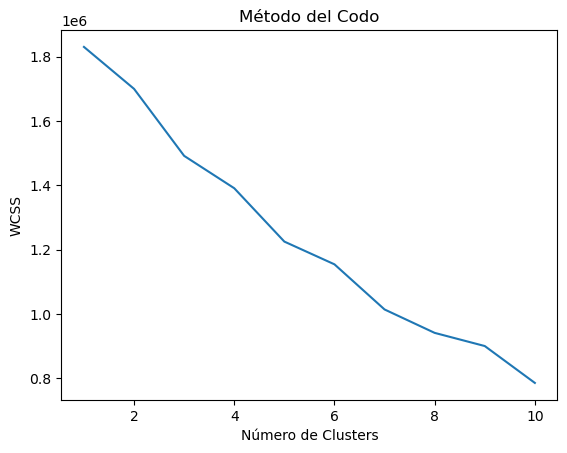

In [7]:
# Método del codo

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Gráfica
plt.plot(range(1, 11), wcss)
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

Se aplicó el método del codo con el objetivo de determinar el número óptimo de clusters para el modelo K-Means. A partir de la gráfica obtenida, se observa una disminución considerable en la suma de cuadrados dentro de los clusters (WCSS) hasta el valor de K = 3.

A partir de este punto, la reducción del WCSS se vuelve más gradual, lo que indica que agregar más clusters no aporta mejoras significativas en la segmentación. Por lo tanto, se seleccionó K = 3 como el número óptimo de clusters, ya que representa un equilibrio adecuado entre la complejidad del modelo y la capacidad de agrupación de los datos.

In [8]:
# Aplicar K-Means (ejemplo con k=3)

kmeans = KMeans(n_clusters = 3, random_state = 42)
clusters = kmeans.fit_predict(df_scaled)

# Evaluar los resultados del clustering:

In [9]:
# Agregar clusters al DataFrame original
df_features['cluster'] = clusters

# Promedio de variables por cluster
df_features.groupby('cluster').mean()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,CATEGORY,REGION_TOTAL AUTOS AREA 2,REGION_TOTAL AUTOS AREA 3,REGION_TOTAL AUTOS AREA 4,REGION_TOTAL AUTOS AREA 5,REGION_TOTAL AUTOS AREA 6,REGION_TOTAL AUTOS SCANNING MEXICO,SEGMENT_BLEACH,SEGMENT_LIQUID & GEL,SEGMENT_OTHERS,SEGMENT_POWDER,SEGMENT_PRETREAT,SEGMENT_SANITIZER
cluster,,,,,,,,,,,,,,,,
0,0.727144,33.014785,3.857617,1.0,0.153581,0.138797,0.144178,0.132842,0.137387,0.164969,0.000000,0.00000,0.000000,0.000000,1.0,0.000000
1,1.183417,55.092975,4.763389,1.0,0.150595,0.138498,0.139349,0.139288,0.138336,0.159328,0.000000,0.45991,0.011347,0.358534,0.0,0.101781
2,5.969906,143.753540,17.255066,1.0,0.151996,0.130896,0.141007,0.125551,0.139344,0.186309,0.995104,0.00000,0.000000,0.000000,0.0,0.000000


In [10]:
# Cantidad de datos por cluster
df_features['cluster'].value_counts()

cluster
2    53508
1    49351
0    19143
Name: count, dtype: int64

## Análisis de Clusters:

A partir de los resultados obtenidos del algoritmo K-Means con K = 3, se identificaron tres grupos claramente diferenciados en función del comportamiento de ventas y características del producto.

### Cluster 0 – Ventas medias con enfoque específico:

Ventas moderadas (TOTAL_VALUE_SALES ≈ 33)

Volumen medio (TOTAL_UNIT_SALES ≈ 0.72)

Predomina el segmento: PRETREAT (100%)

Distribución regional equilibrada

Este cluster representa productos con un desempeño estable pero no dominante, enfocados en un tipo específico de solución (pretratamiento de manchas).

Productos nicho.

Potencial de crecimiento con marketing dirigido.

### Cluster 1 – Portafolio diversificado

Ventas más altas que el cluster 0 (≈ 55)

Mayor volumen (≈ 1.18)

Mezcla de segmentos:

Liquid & Gel

Powder

Sanitizer

Distribución regional similar

Este cluster agrupa productos con mayor variedad y presencia en múltiples segmentos, lo que indica una estrategia más diversificada.

Portafolio equilibrado.

Buen desempeño general.

Representa el “core” del negocio.

### Cluster 2 – Alto rendimiento (productos estrella)

Ventas muy altas (≈ 143)

Alto volumen (≈ 5.96)

Promedio semanal alto (≈ 17)

Dominado por:

BLEACH (≈ 99%)

Este cluster representa los productos más importantes y rentables, con un desempeño muy superior al resto.

Productos estrella.

Alta demanda.

Probablemente clave para la marca Vanish.

## Conclusión

El análisis de clustering permitió identificar tres segmentos claramente diferenciados en función del comportamiento de ventas y características de los productos. Se detectó un grupo de productos de alto rendimiento que concentra la mayor parte de las ventas, un grupo intermedio con desempeño sólido y diversificado, y un grupo con ventas moderadas enfocado en nichos específicos.

Estos resultados permiten a la empresa Vanish identificar oportunidades estratégicas, como potenciar los productos estrella, optimizar el portafolio intermedio y desarrollar estrategias de crecimiento para los segmentos con menor desempeño.

## Recomendaciones Estratégicas basadas en clustering

A partir de la segmentación obtenida mediante K-Means, se proponen las siguientes estrategias para la empresa aliada Vanish:

#### 1. Potenciar productos estrella (Cluster 2)

- Dado que este grupo presenta:

Mayor volumen de ventas.

Mayor valor económico.

Alta frecuencia de compra.

- Recomendaciones:

Aumentar inversión en marketing y publicidad.

Garantizar disponibilidad (evitar quiebres de stock).

Expandir distribución en todas las regiones.

Crear promociones para fidelización.

Convertir estos productos en el motor principal de ingresos.

#### 2. Optimizar portafolio diversificado (Cluster 1)

Este grupo tiene:

Buen desempeño.

Diversidad de segmentos.

Recomendaciones:

Analizar qué subcategorías son más rentables.

Enfocar campañas específicas por tipo de producto.

Reducir productos con bajo desempeño dentro del cluster.

Optimización y especialización del portafolio.

#### 3. Impulsar productos de bajo rendimiento (Cluster 0)

Este cluster muestra:

Ventas moderadas.

Enfoque en nichos específicos.

Recomendaciones:

Implementar promociones o descuentos.

Mejorar posicionamiento en punto de venta.

Evaluar si conviene mantener o reemplazar productos.

Decidir entre crecer o depurar.

#### 4. Estrategia regional

Dado que la distribución regional es bastante uniforme.

Recomendaciones:

Aplicar estrategias diferenciadas por región.

Identificar regiones con mayor potencial de crecimiento.

Adaptar campañas según comportamiento local.

# Conclusión

Se evaluaron los resultados obtenidos del modelo de clustering, asignando cada observación a un grupo específico mediante el algoritmo K-Means. Cada cluster representa un conjunto de productos con características similares en términos de ventas, volumen y tipo de segmento.

Posteriormente, se analizaron las características promedio de cada cluster, lo que permitió identificar patrones relevantes. Se detectó un grupo de productos con alto rendimiento en ventas, principalmente asociados al segmento de blanqueadores, los cuales representan una parte significativa del valor total.

Asimismo, se identificó un cluster con desempeño intermedio y mayor diversidad de segmentos, lo que indica un portafolio equilibrado, así como un grupo con menor rendimiento enfocado en productos más específicos.

Estos hallazgos permiten comprender mejor la estructura del mercado, facilitando la identificación de oportunidades de mejora en términos de estrategia comercial, segmentación y posicionamiento.

# Visualizar los clusters:

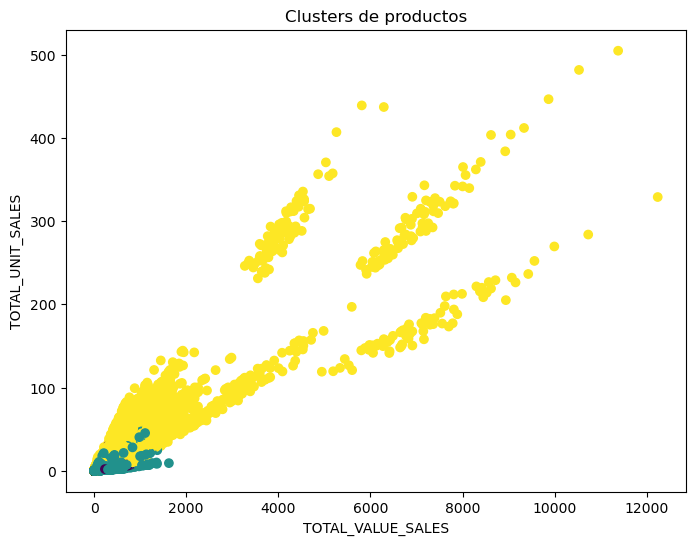

In [11]:
# Gráfico de dispersión

# Se usan las variables más representativas: TOTAL_VALUE_SALES y TOTAL_UNIT_SALES

import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))

# Scatter
plt.scatter(df_features['TOTAL_VALUE_SALES'], df_features['TOTAL_UNIT_SALES'], c = df_features['cluster'])

# Labels
plt.xlabel('TOTAL_VALUE_SALES')
plt.ylabel('TOTAL_UNIT_SALES')
plt.title('Clusters de productos')

plt.show()

Se distinguen tres grupos bien definidos.

Hay una clara separación por nivel de ventas:

Cluster 0 → zona inferior (bajas ventas). Color Negro

Cluster 1 → zona media (ventas moderadas). Color Azul

Cluster 2 → zona superior (altas ventas). Color Amarillo

Se observa una tendencia positiva: a mayor valor de ventas, mayor volumen

El modelo K-Means logró separar adecuadamente los datos en función del comportamiento de ventas, generando grupos con diferencias claras en desempeño.

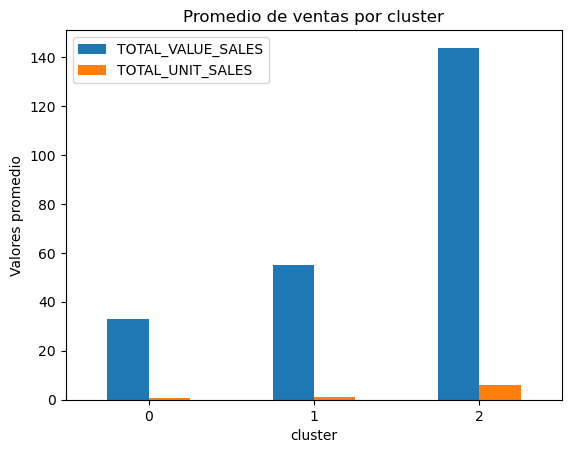

In [16]:
# Gráfico de barras (promedio por cluster)

df_features.groupby('cluster')[['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES']].mean().plot(kind = 'bar')

plt.title('Promedio de ventas por cluster')
plt.ylabel('Valores promedio')
plt.xticks(rotation = 360)

plt.show()

El Cluster 2 domina completamente en:

TOTAL_VALUE_SALES

TOTAL_UNIT_SALES

Cluster 1 está en nivel intermedio.

Cluster 0 es el más bajo.

Esto confirma que:

Cluster 2 = productos estrella

Cluster 1 = desempeño medio

Cluster 0 = bajo rendimiento

Este gráfico valida perfectamente el clustering

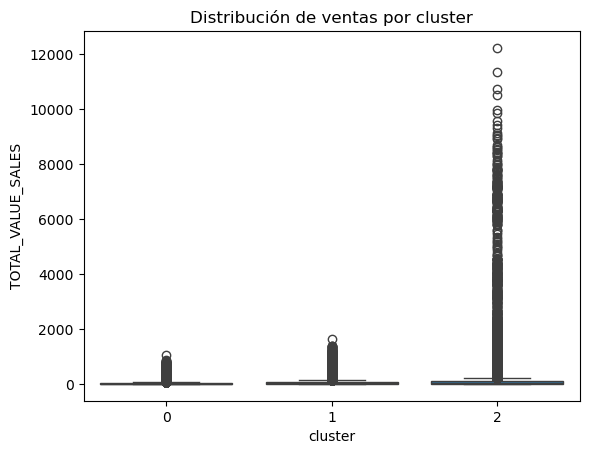

In [17]:
# Boxplot 

import seaborn as sns

sns.boxplot(x='cluster', y='TOTAL_VALUE_SALES', data=df_features)

plt.title('Distribución de ventas por cluster')
plt.show()

Cluster 2 tiene:

Mayor dispersión.

Muchos valores atípicos (outliers altos).

Cluster 0 y 1 están más concentrados.

Se ve claramente la diferencia de escalas entre clusters.

El Cluster 2 no solo vende más, sino que tiene mayor variabilidad.

Indica que hay productos extremadamente exitosos dentro de ese grupo.

Los otros clusters son más estables pero menos rentables.

# Conclusión

Las visualizaciones generadas permiten validar la efectividad del modelo de clustering. El gráfico de dispersión muestra una clara separación entre los grupos, evidenciando diferencias significativas en el comportamiento de ventas.

El gráfico de barras confirma que uno de los clusters concentra los valores más altos tanto en ventas como en volumen, mientras que los otros presentan niveles intermedios y bajos. Por su parte, el diagrama de caja revela la existencia de una mayor dispersión en el cluster de alto rendimiento, lo que indica la presencia de productos altamente exitosos dentro de este grupo.

En conjunto, estos resultados refuerzan la validez del modelo y permiten identificar segmentos clave para la toma de decisiones estratégicas de la empresa aliada Vanish.

# Interpretar y analizar los clusters:

A partir de los resultados obtenidos del análisis de clustering, se identificaron insights clave que permiten comprender mejor el comportamiento de los productos y su desempeño en el mercado.

En primer lugar, se detectó un cluster con alto rendimiento, caracterizado por elevados niveles de ventas y volumen. Este grupo está fuertemente asociado a productos del segmento de blanqueadores, lo que indica que esta categoría representa una de las principales fortalezas dentro del portafolio de la empresa aliada Vanish. Estos productos pueden considerarse como estratégicos y deben ser priorizados en términos de inversión, distribución y posicionamiento.

Por otro lado, se identificó un cluster con desempeño intermedio que agrupa productos de diferentes segmentos, como líquidos, geles y otros formatos. Este comportamiento sugiere un portafolio diversificado que mantiene un nivel de ventas estable, aunque con oportunidades de optimización. En este caso, resulta conveniente analizar qué subcategorías o atributos generan mayor rentabilidad para enfocar los esfuerzos comerciales de manera más eficiente.

Finalmente, se observó un cluster con bajo rendimiento, compuesto principalmente por productos con menores niveles de ventas y menor rotación. Este grupo podría estar asociado a nichos específicos o a productos con menor aceptación en el mercado. Un patrón relevante es la concentración en ciertos segmentos como pretratamiento, lo que podría indicar una menor demanda o menor visibilidad de estos productos.

Asimismo, el análisis muestra que la distribución geográfica es relativamente homogénea entre los clusters, lo que sugiere que las diferencias en desempeño no están fuertemente determinadas por la región, sino más bien por las características del producto y su posicionamiento.

En conjunto, estos hallazgos permiten identificar oportunidades claras de mejora, como potenciar los productos de alto rendimiento, optimizar el portafolio intermedio y replantear la estrategia para los productos de bajo desempeño, ya sea mediante campañas específicas, ajustes en precios o incluso la descontinuación de ciertos productos.

# Guardar los resultados y el modelo:

In [19]:
# Agregar cluster al dataset original
df_sales['cluster'] = clusters

# Guardar dataset completo
df_sales.to_csv('resultados_completos_clustering.csv', index = False)

Finalmente, se guardaron los resultados del análisis de clustering en un archivo CSV, incluyendo la asignación de cada observación a su respectivo cluster.